In [2]:
import numpy as np
import struct
import os
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

In [3]:
def ibm_to_ieee(ibm_array):
    ibm = ibm_array.astype(np.uint32)

    sign = ((ibm >> 31) & 0x01).astype(np.float32)
    exponent = ((ibm >> 24) & 0x7F).astype(np.int32)
    fraction = (ibm & 0x00FFFFFF).astype(np.float64)

    fraction = fraction / float(0x1000000)
    sign = np.where(sign == 0, 1.0, -1.0)

    ieee = sign * fraction * np.power(16.0, exponent - 64)

    return ieee.astype(np.float32)

In [4]:
filename = "lineD.sgy"
filesize = os.path.getsize(filename)

with open(filename, "rb") as f:
    textual_header = f.read(3200)
    binary_header = f.read(400)
print("File size (bytes):", filesize)

FileNotFoundError: [WinError 2] The system cannot find the file specified: 'lineD.sgy'

In [5]:
print("TEXTUAL HEADER (EBCDIC)")
print(textual_header.decode("cp500"))

TEXTUAL HEADER (EBCDIC)


NameError: name 'textual_header' is not defined

In [18]:
def display_textual_header(textual_header):
    header_text = textual_header.decode("cp500")
    
    print("\n" + "="*60)
    print("SEG-Y TEXTUAL HEADER (EBCDIC DECODED)")
    print("="*60)
    
    for i in range(40):
        line = header_text[i*80:(i+1)*80]
        print(f"{i+1:02d} | {line}")
    
    print("="*60)

In [19]:
display_textual_header(textual_header)


SEG-Y TEXTUAL HEADER (EBCDIC DECODED)
01 | C 1 CLIENT                        COMPANY                       CREW NO         
02 | C 2 LINE            AREA                        MAP ID                          
03 | C 3 REEL NO           DAY-START OF REEL     YEAR      OBSERVER                  
04 | C 4 INSTRUMENT: MFG            MODEL            SERIAL NO                       
05 | C 5 DATA TRACES/RECORD        AUXILIARY TRACES/RECORD         CDP FOLD          
06 | C 6 SAMPLE INTERNAL         SAMPLES/TRACE       BITS/IN      BYTES/SAMPLE       
07 | C 7 RECORDING FORMAT        FORMAT THIS REEL        MEASUREMENT SYSTEM          
08 | C 8 SAMPLE CODE: FLOATING PT     FIXED PT     FIXED PT-GAIN     CORRELATED      
09 | C 9 GAIN  TYPE: FIXED     BINARY     FLOATING POINT     OTHER                   
10 | C10 FILTERS: ALIAS     HZ  NOTCH     HZ  BAND    -     HZ  SLOPE    -    DB/OCT 
11 | C11 SOURCE: TYPE            NUMBER/POINT        POINT INTERVAL                  
12 | C12     PA

In [20]:
dt = struct.unpack(">h", binary_header[16:18])[0]
ns = struct.unpack(">h", binary_header[20:22])[0]
fmt = struct.unpack(">h", binary_header[24:26])[0]

print("BINARY HEADER INFORMATION")
print(f"Sample interval       : {dt} microseconds")
print(f"Samples per trace     : {ns}")
print(f"Data sample format    : {fmt} (1 = IBM float)")

BINARY HEADER INFORMATION
Sample interval       : 4000 microseconds
Samples per trace     : 1001
Data sample format    : 1 (1 = IBM float)


In [21]:
trace_header_bytes = 240
sample_bytes = 4
trace_size = trace_header_bytes + ns * sample_bytes

n_traces = (filesize - 3600) // trace_size

print(f"Computed number of traces: {n_traces}")

Computed number of traces: 207


In [22]:
data = []

with open(filename, "rb") as f:
    f.seek(3600)

    for _ in range(n_traces):
        trace_header = f.read(trace_header_bytes)
        raw_trace = f.read(ns * sample_bytes)

        ibm_trace = np.frombuffer(raw_trace, dtype=">u4")
        trace = ibm_to_ieee(ibm_trace)

        data.append(trace)

data = np.array(data).T

print("\nSeismic matrix shape:", data.shape)


Seismic matrix shape: (1001, 207)


In [23]:
dt_sec = dt / 1e6
time = np.arange(ns) * dt_sec

print("Record length (seconds):", time[-1])

Record length (seconds): 4.0


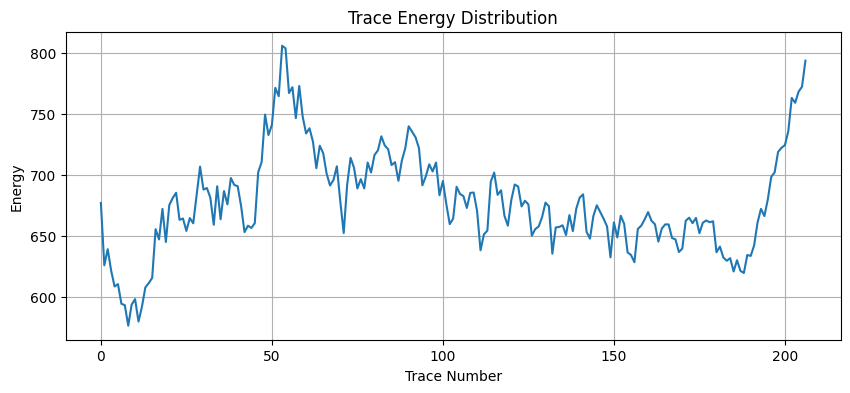

In [24]:
trace_energy = np.sum(np.abs(data), axis=0)

plt.figure(figsize=(10,4))
plt.plot(trace_energy)
plt.title("Trace Energy Distribution")
plt.xlabel("Trace Number")
plt.ylabel("Energy")
plt.grid(True)
plt.show()

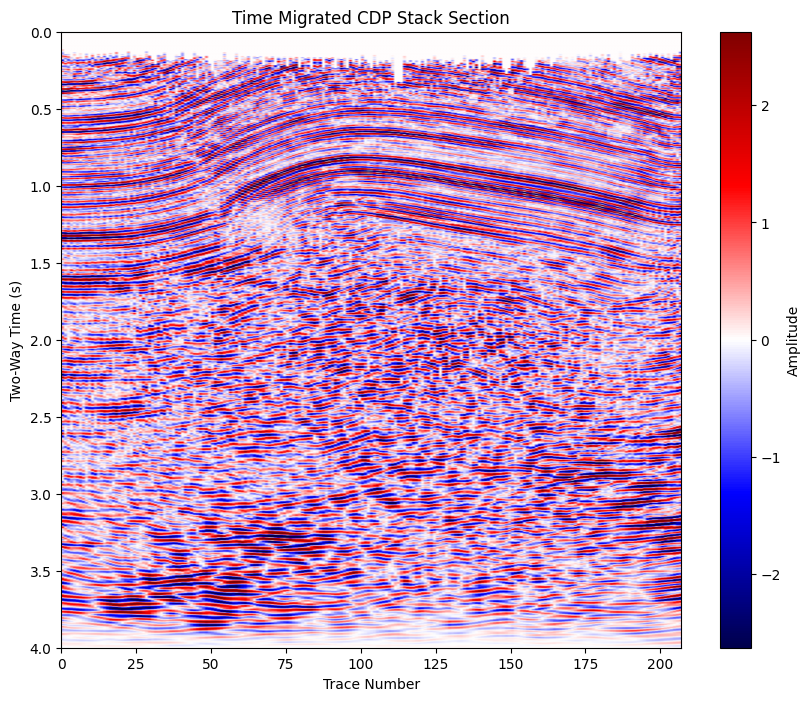

In [25]:
vmax = np.percentile(np.abs(data), 99)

plt.figure(figsize=(10,8))
plt.imshow(
    data,
    cmap="seismic",
    aspect="auto",
    vmin=-vmax,
    vmax=vmax,
    extent=[0, n_traces, time[-1], time[0]]
)
plt.xlabel("Trace Number")
plt.ylabel("Two-Way Time (s)")
plt.title("Time Migrated CDP Stack Section")
plt.colorbar(label="Amplitude")
plt.show()

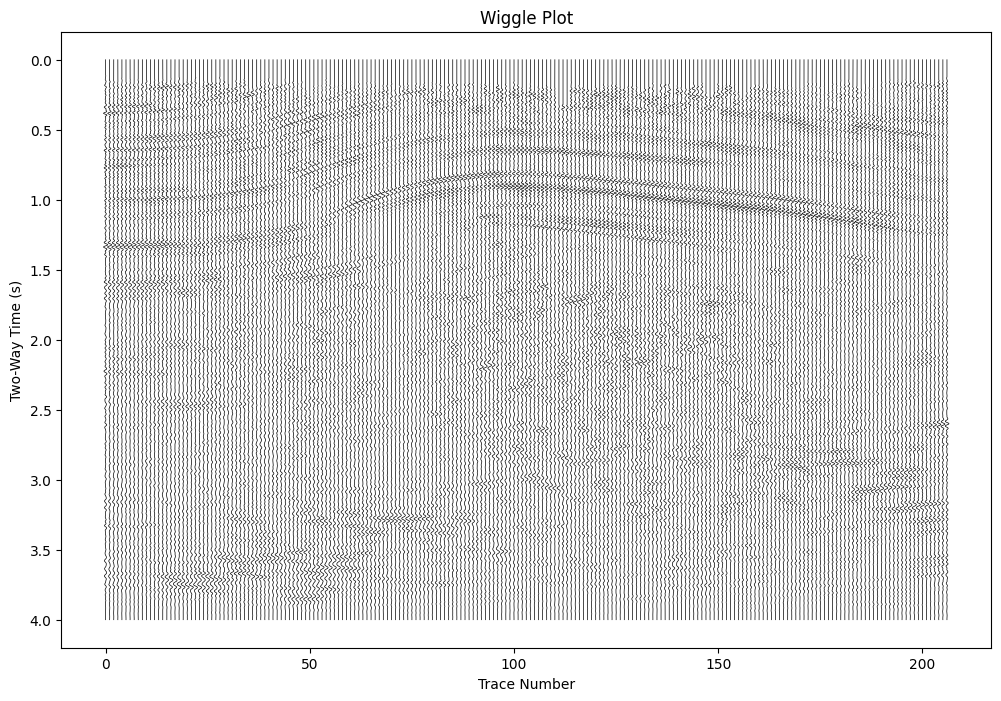

In [26]:
plt.figure(figsize=(12,8))

scale = 0.5

for i in range(n_traces):
    trace = data[:, i]
    if np.max(np.abs(trace)) > 0:
        trace_norm = trace / np.max(np.abs(trace))
        plt.plot(i + trace_norm * scale, time, color="black", linewidth=0.5)

plt.gca().invert_yaxis()
plt.xlabel("Trace Number")
plt.ylabel("Two-Way Time (s)")
plt.title("Wiggle Plot")
plt.show()